# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import ttest_1samp, norm
from scipy.integrate import quad 

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.dgp import RCTs, DataGenerationProcess
import core.rct as rct
from core.variables import *
from core.utils import *

# DGP

In [ ]:
# bernoulli specification
dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.11)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

# # continuous specification
# dgp_params = {
#     'n_experiments': 1, 
#     'base_effects': [PointMass(1), PointMass(1.05)],
#     'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
#     'dgp_seed': 0
# }

# # logit specification
# dgp_params = {
#     'n_experiments': 1, 
#     'base_effects': [PointMass(np.log(1 / 9)), PointMass(np.log(11 / 89))],
#     'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
#     'response_type': 'logit', 
#     'dgp_seed': 0
# }

dgp = RCTs(**dgp_params)

In [353]:
samples = dgp.sample(sample_size=1000000, seed=0)

# Estimation

In [156]:
emp_te_arr, emp_var_arr = rct.estimate_treatment_effects(samples, response_type=dgp.response_type)

# Selection

In [157]:
selection = rct.select_higher_effect(treatment_effects=emp_te_arr, treatment_vars=emp_var_arr)

# Evaluation

In [158]:
val_est = rct.obj_func(selection=selection, treatment_effects=emp_te_arr, response_type=dgp.response_type,)
val_true = rct.obj_func(selection=selection, treatment_effects=dgp.treatment_effects, response_type=dgp.response_type,)

result_df = pd.DataFrame({
    'Rank and Select': [val_est, val_true, val_est - val_true]
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Rank and Select
Estimated Policy Value,0.11
True Policy Value,0.11
Winner's Curse,0.00


In [12]:
del dgp, samples, emp_te_arr, selection, val_est, val_true, result_df

# Winner's Curse

In [6]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.025)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}


data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 5000}

estimators_dict = {}

result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 1600 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 4640 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    2.9s finished


In [7]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.6f} ({val_true_se:.6f})')
    print(f'  - Average Estimated Value: {val_est_avg:.6f} ({val_est_se:.6f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.4%} ({wc_se/delta_tau:.4%})')


Selection with Rank and Select:
  - Average True Value: 1.016555 (0.000529)
  - Average Estimated Value: 1.040462 (0.001696)
  - Average Winner's Curse (%): 95.6283% (6.8896%)


# Estimating Winner's Curse

In [8]:
dgp = RCTs(**dgp_params)
samples = dgp.sample(sample_size=data_params['sample_size'], seed=0)

## Standard Bootstrap

In [22]:
boot_wc_dstn_dict = rct.get_wc_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    response_type=dgp.response_type,
    n_bootstraps=5000, n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 228 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 3635 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    1.9s finished


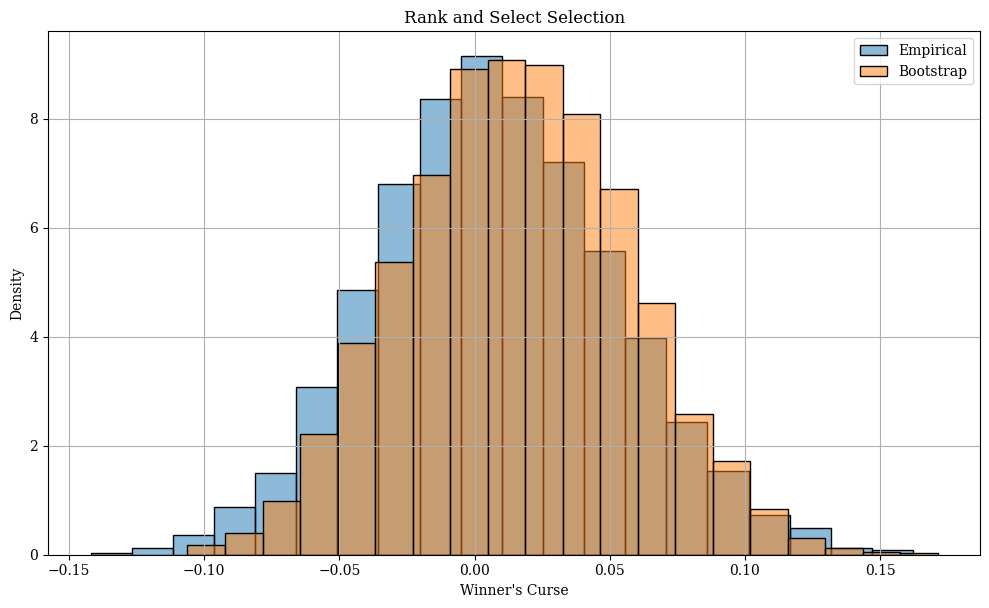

In [21]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [ ]:
boot_wc_dstn_dict = rct.get_wc_m_out_of_n_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    response_type=dgp.response_type,
    n_bootstraps=1000, power=0.95, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


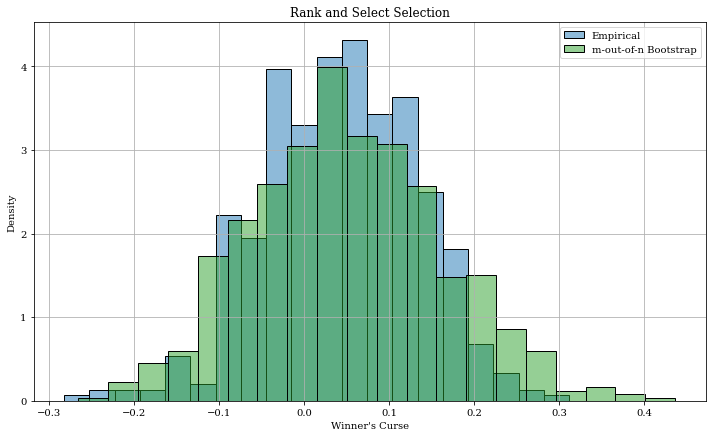

In [ ]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [ ]:
boot_wc_dstn_dict = rct.get_wc_num_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    response_type=dgp.response_type, 
    n_bootstraps=1000, power=-0.45, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


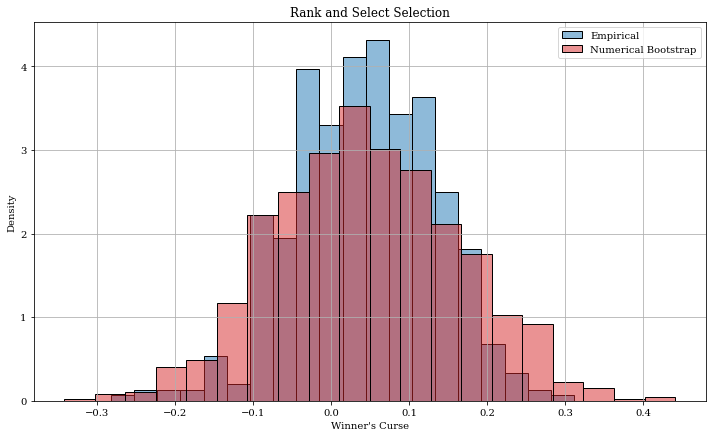

In [ ]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [ ]:
del dgp, samples, boot_wc_dstn_dict

# Bias Correction

In [90]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.05)],
    'response_type': 'continuous', 
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    # 'eb_tweedies': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'tweedies', 'dof': 3, 'bin_width': 0.2, 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Tweedies)'
    # }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI'
    }, 
}

In [91]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.6s finished


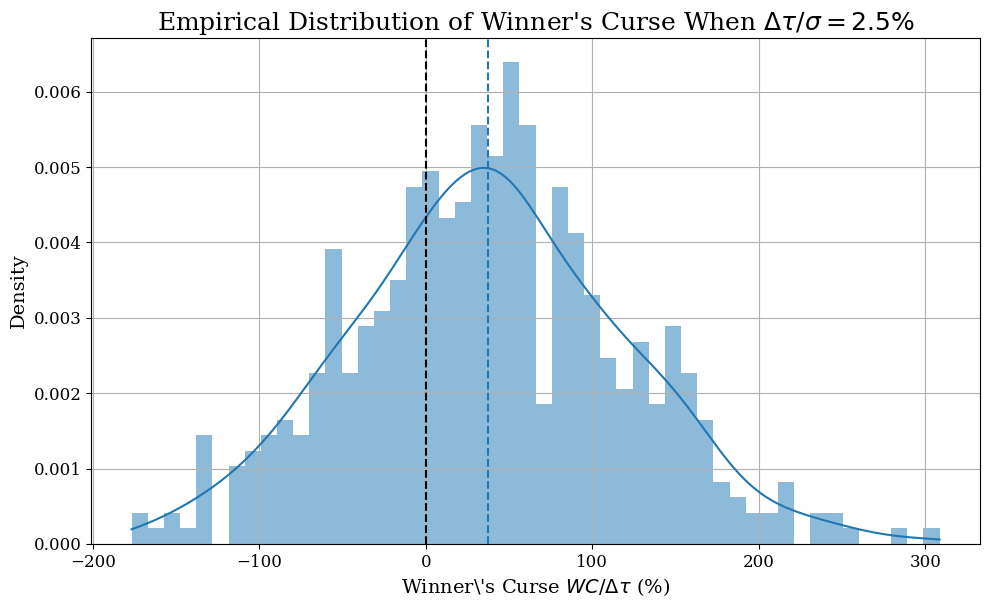

In [92]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean
wc_dstn = wc_measures_dict[f'{optimizer_name}_nc_wc_arr'] / delta_tau * 100

# no correction
sns.histplot(wc_dstn, bins=50, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax, edgecolor=None, kde=True)
ax.axvline(wc_dstn.mean(), color='C0', linestyle='--', label='Empirical Mean')

# # standard bootstrap
# wc_boot_dstn = wc_measures_dict[f'{optimizer_name}_standard_bootstrap_wc_arr'] / delta_tau * 100
# sns.histplot(wc_boot_dstn, bins=50, color='C1', alpha=0.5, stat='density', label='Standard Bootstrap', ax=ax, edgecolor=None, kde=True)
# ax.axvline(wc_boot_dstn.mean(), color='C1', linestyle='--', label='Standard Bootstrap Mean')

# zero
ax.axvline(0, color='black', linestyle='--', label='Zero')

ax.set_title(r"Empirical Distribution of Winner's Curse When $\Delta\tau/\sigma = 2.5\%$", fontsize=title_size)
ax.set_xlabel(r'Winner\'s Curse $WC/\Delta\tau$ (%)', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
# ax.legend()
ax.grid()

plt.tight_layout()
plt.show()


Selection with Rank and Select:
Policy Value: 
  - True Value: 1.0393 (0.0009)
  - No Correction: 1.0579 (0.0018)
  - Standard Bootstrap: 1.0430 (0.0021)
  - m-out-of-n Bootstrap: 1.0385 (0.0021)
  - Numerical Bootstrap: 1.0374 (0.0022)
  - Empirical Bayes: 1.0414 (0.0017)
  - Conditional SI: 0.9913 (0.0139)
  - Hybrid SI: 1.0318 (0.0030)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 37.28% (3.66%)
  - Standard Bootstrap: 7.42% (4.03%)
  - m-out-of-n Bootstrap: -1.56% (4.06%)
  - Numerical Bootstrap: -3.77% (4.18%)
  - Empirical Bayes: 4.12% (3.56%)
  - Conditional SI: -96.01% (27.65%)
  - Hybrid SI: -15.08% (5.66%)
Median Winner's Curse: 
  - No Correction: 36.58% (3.66%)
  - Standard Bootstrap: 5.58% (4.03%)
  - m-out-of-n Bootstrap: -3.47% (4.06%)
  - Numerical Bootstrap: -8.08% (4.18%)
  - Empirical Bayes: 2.66% (3.56%)
  - Conditional SI: 2.38% (27.65%)
  - Hybrid SI: 2.55% (5.66%)

Sample Splitting: 
  - True Value: 1.0350 (0.0010)
  - Estimated Value: 1.0369 (0.

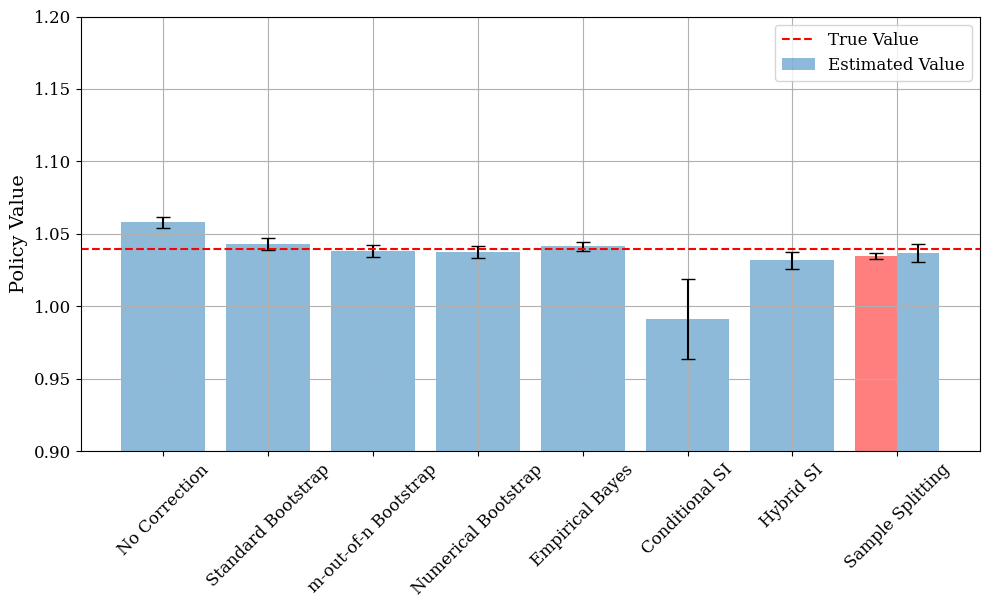

In [93]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()]
    )
ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


In [94]:
np.mean(wc_measures_dict[f'{optimizer_key}_conditional_si_val_est_arr']), np.mean(wc_measures_dict[f'{optimizer_key}_conditional_si_wc_arr'])/ 0.05 * 100

(0.9912943212834827, -96.01135743303469)

In [95]:
np.median(wc_measures_dict[f'{optimizer_key}_conditional_si_val_est_arr']), np.median(wc_measures_dict[f'{optimizer_key}_conditional_si_wc_arr'])/ 0.05 * 100

(1.0432993866966709, 2.379718911583728)

In [96]:
np.median(wc_measures_dict[f'{optimizer_key}_hybrid_si_val_est_arr']), np.median(wc_measures_dict[f'{optimizer_key}_hybrid_si_wc_arr']) / 0.05 * 100

(1.0433732068920367, 2.55142637864747)

In [97]:
optimizer_key= 'rank_and_select'
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean
latex_dict = {}

# true value
val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
latex_dict["True Value"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${val_true_avg:.4f}$\\\\ (${val_true_se:.4f}$)" + "\end{tabular}", 
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${0:.2f}\%$\\\\ (${0:.2f}\%$)" + "\end{tabular}"
}

for e_key in ['nc'] + list(estimators_dict.keys()):
    if e_key == 'sample_splitting':
        continue
    
    est_mean = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_se']

    wc_mean = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_avg']
    wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_se']
    wc_sig_level = significance_level(wc_mean, wc_se)
    wc_sig_level = '^{' + wc_sig_level + '}' if wc_sig_level != '' else ''

    e_name =  estimators_dict[e_key]['display_name'] if e_key != 'nc' else 'No Correction'

    latex_dict[e_name] = {
        'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${est_mean:.4f}" + f"$\\\\ (${est_se:.4f}$)" + "\end{tabular}", 
        r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + wc_sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    }

# sample splitting
ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']

ss_wc_avg = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
ss_wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']
ss_wc_sig_level = significance_level(ss_wc_avg, ss_wc_se)
ss_wc_sig_level = '^{' + ss_wc_sig_level + '}' if ss_wc_sig_level != '' else ''
latex_dict["Sample Splitting"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_est_avg:.4f}" + f"$\\\\ (${ss_val_est_se:.4f}$)" + "\end{tabular}",
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_wc_avg:.2f}\%" + ss_wc_sig_level + f"$\\\\ (${ss_wc_se:.2f}\%$)" + "\end{tabular}"
}

latex_df = pd.DataFrame(latex_dict).T
print(latex_df.style.to_latex(
    column_format='ccc',  
    hrules=True
))

\begin{tabular}{ccc}
\toprule
 & Policy Value & \begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular} \\
\midrule
True Value & \begin{tabular}[c]{@{}c@{}}$1.0393$\\ ($0.0009$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.00\%$\\ ($0.00\%$)\end{tabular} \\
No Correction & \begin{tabular}[c]{@{}c@{}}$1.0579$\\ ($0.0018$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$37.28\%^{***}$\\ ($3.66\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$1.0430$\\ ($0.0021$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.42\%^{*}$\\ ($4.03\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$1.0385$\\ ($0.0021$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-1.56\%$\\ ($4.06\%$)\end{tabular} \\
Numerical Bootstrap & \begin{tabular}[c]{@{}c@{}}$1.0374$\\ ($0.0022$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-3.77\%$\\ ($4.18\%$)\end{tabular} \\
Empirical Bayes & \begin{tabular}[c]{@{}c@{}}$1.0414$\\ ($0.0017$)\end{tabular} & \begin{tabular}[c]{@{}c

In [98]:
nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
clairvoyant_val = np.max([var.mean for var in dgp_params['base_effects']])
policy_comp_dict = {
    'Clairvoyant Policy': {'Policy Value': f"{clairvoyant_val:.4f}"}, 
    'Focal Policy': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"},
}

ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
random_val = np.mean([var.mean for var in dgp_params['base_effects']])
policy_comp_dict.update({
    'Sample Splitting': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"}, 
    'Random Guessing': {'Policy Value': f'{random_val:.4f}'},
})

policy_comp_df = pd.DataFrame(policy_comp_dict).T
print(policy_comp_df.style.to_latex(
    column_format='cc',  
    hrules=True
))

\begin{tabular}{cc}
\toprule
 & Policy Value \\
\midrule
Clairvoyant Policy & 1.0500 \\
Focal Policy & \begin{tabular}[c]{@{}c@{}}$1.0393$\\ ($0.0009$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$1.0350$\\ ($0.0010$)\end{tabular} \\
Random Guessing & 1.0250 \\
\bottomrule
\end{tabular}



# Comparative Statics

## Delta Tau

In [6]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'plugin_correction': {
        'estimator': rct.plugin_correction_estimate, 
        'params': {}, 
        'display_name': 'Plugin Correction', 
    }, 
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

In [11]:
base_tau = 1.0
delta_tau_list = [0.01, 0.025, 0.05]

delta_tau1_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [PointMass(base_tau), PointMass(base_tau + delta_tau)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau1_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.025
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.05
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished


In [14]:
with open('results/ab_test_delta_tau1.pkl', 'wb') as f:
    pickle.dump(delta_tau1_result_dict, f)

with open('results/ab_test_delta_tau1.pkl', 'rb') as f:
    delta_tau1_result_dict = pickle.load(f)

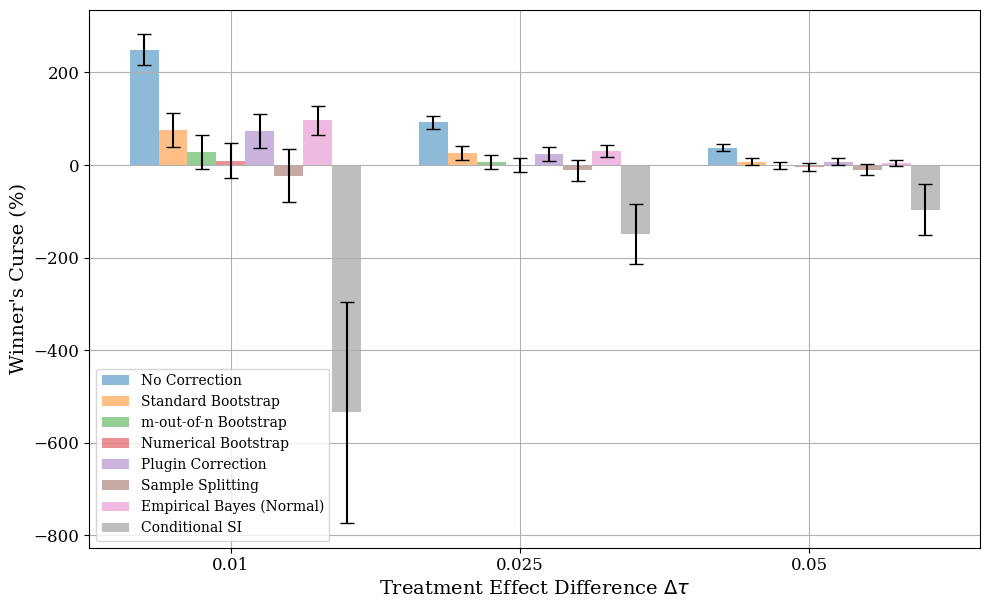

$\Delta\tau=0.01$  $\Delta\tau=0.025$  \
No Correction            Mean               249.24               92.30   
                         Median             241.51               89.38   
                         S.E.                16.81                7.01   
Standard Bootstrap       Mean                75.07               25.13   
                         Median              41.37               16.82   
                         S.E.                18.60                7.73   
m-out-of-n Bootstrap     Mean                28.67                6.60   
                         Median              -7.21               -1.17   
                         S.E.                18.69                7.77   
Numerical Bootstrap      Mean                 9.73                0.12   
                         Median             -24.73              -14.03   
                         S.E.                19.32                8.03   
Plugin Correction        Mean                73.77               24.57   
                         Median              46.12               14.64   
                         S.E.                18.57                7.71   
Sample Splitting         Mean               -23.27              -11.68   
                         Median             -43.46               -8.30   
                         S.E.                29.22               12.03   
Empirical Bayes (Normal) Mean                96.40               29.78   
                         Median              85.21               24.70   
                         S.E.                15.79                6.64   
Conditional SI           Mean              -534.45             -148.50   
                         Median              12.94               -2.52   
                         S.E.               122.13               32.72   

                                 $\Delta\tau=0.05$  
No Correction            Mean                37.28  
                         Median              36.58  
                         S.E.                 3.66  
Standard Bootstrap       Mean                 7.54  
                         Median               4.99  
                         S.E.                 4.03  
m-out-of-n Bootstrap     Mean                -1.49  
                         Median              -4.32  
                         S.E.                 4.06  
Numerical Bootstrap      Mean                -3.56  
                         Median              -7.19  
                         S.E.                 4.18  
Plugin Correction        Mean                 7.25  
                         Median               4.80  
                         S.E.                 4.02  
Sample Splitting         Mean               -10.45  
                         Median              -8.74  
                         S.E.                 6.14  
Empirical Bayes (Normal) Mean                 4.12  
                         Median               2.66  
                         S.E.                 3.56  
Conditional SI           Mean               -96.01  
                         Median               2.38  
                         S.E.                27.65

In [15]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau1_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Treatment Effect Difference $\Delta\tau$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [16]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau1_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    wc_mean = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[delta_tau]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[delta_tau][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
sigma = dgp_params['noise_vars'][0].std
latex_df.columns = [f'$\Delta\\tau / \sigma={100 * delta_tau / sigma:.1f}\%$' for delta_tau in delta_tau_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(delta_tau_list) + 1), 
    hrules=True
))

\begin{tabular}{cccc}
\toprule
 & $\Delta\tau / \sigma=1.0\%$ & $\Delta\tau / \sigma=2.5\%$ & $\Delta\tau / \sigma=5.0\%$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$249.24\%^{***}$\\ ($16.81\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$92.30\%^{***}$\\ ($7.01\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$37.28\%^{***}$\\ ($3.66\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$75.07\%^{***}$\\ ($18.60\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$25.13\%^{***}$\\ ($7.73\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.54\%^{*}$\\ ($4.03\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$28.67\%$\\ ($18.69\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$6.60\%$\\ ($7.77\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-1.49\%$\\ ($4.06\%$)\end{tabular} \\
Numerical Bootstrap & \begin{tabular}[c]{@{}c@{}}$9.73\%$\\ ($19.32\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.12\%$\\ ($8.03\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-3.

In [17]:
policy_comp_dict = {
    'Clairvoyant Policy': {}, 
    'Policy (Entire Dataset)': {},
    'Policy (Half Dataset)': {},
    'Random Guessing': {}, 
}

for delta_tau, wc_measures_dict in delta_tau1_result_dict.items():
    ratio = delta_tau / 1.0 * 100
    # clairvoyant policy
    clairvoyant_val = 1 + delta_tau
    policy_comp_dict['Clairvoyant Policy'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = f"{clairvoyant_val:.4f}"

    # focal policy
    nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
    nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
    policy_comp_dict['Policy (Entire Dataset)'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"

    # sample splitting
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    policy_comp_dict['Policy (Half Dataset)'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"

    # random guessing policy 
    random_val = 1 + delta_tau / 2 
    policy_comp_dict['Random Guessing'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = f'{random_val:.4f}'

# Create DataFrame
policy_comp_df = pd.DataFrame(policy_comp_dict).T 
policy_comp_df
print(policy_comp_df.style.to_latex(
    column_format='cccc',  
    hrules=True
))

\begin{tabular}{cccc}
\toprule
 & $\Delta\tau / \sigma = 1.0\%$ & $\Delta\tau / \sigma = 2.5\%$ & $\Delta\tau / \sigma = 5.0\%$ \\
\midrule
Clairvoyant Policy & 1.0100 & 1.0250 & 1.0500 \\
Policy (Entire Dataset) & \begin{tabular}[c]{@{}c@{}}$1.0056$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0167$\\ ($0.0005$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0393$\\ ($0.0009$)\end{tabular} \\
Policy (Half Dataset) & \begin{tabular}[c]{@{}c@{}}$1.0056$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0152$\\ ($0.0005$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0354$\\ ($0.0010$)\end{tabular} \\
Random Guessing & 1.0050 & 1.0125 & 1.0250 \\
\bottomrule
\end{tabular}



## Sample Size

In [18]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.05), PointMass(1.10)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 5000}

estimators_dict = {
    # 'sample_splitting': {
    #     'estimator': rct.sample_splitting_estimate,
    #     'params': {'estimation_split': 0.5},
    #     'display_name': 'Sample Splitting'
    # }, 
    # 'standard_bootstrap': {
    #     'estimator': rct.bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
    #     'display_name': 'Standard Bootstrap', 
    # }, 
    # 'm_out_of_n_bootstrap': {
    #     'estimator': rct.bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
    #     'display_name': 'm-out-of-n Bootstrap', 
    # },
    # 'numerical_bootstrap': {
    #     'estimator': rct.bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
    #     'display_name': 'Numerical Bootstrap', 
    # }, 
    # 'eb_normal': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Normal)'
    # }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    # 'conditional_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Conditional SI'
    # }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

sample_size_list = [100, 200, 500, 1000, 2500, 5000, 7500, 10000, 25000, 50000, 75000, 100000]

In [19]:
sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True, truncate_lb=-3.0, truncate_ub=3.0
    )


Sample Size = 100
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 4161 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Sample Size = 200
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 4150 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Sample Size = 500
Running 5000 experiments...


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4274 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    2.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:    0.0s



Sample Size = 75000
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    2.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s



Sample Size = 100000
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 3180 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    4.2s finished


In [20]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# # no correction
# wc_avg_arr = np.array([sample_size_result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'] for sample_size in sample_size_list]) / delta_tau * 100
# wc_se_arr = np.array([sample_size_result_dict[sample_size][f'{optimizer_key}_nc_wc_se'] for sample_size in sample_size_list]) / delta_tau * 100

# ax.plot(sample_size_list, wc_avg_arr, color='C0', label='No Correction', marker='o')
# ax.fill_between(
#     sample_size_list, 
#     wc_avg_arr - 1.96 * wc_se_arr, 
#     wc_avg_arr + 1.96 * wc_se_arr, color='C0', alpha=0.2
# )

# # standard bootstrap
# wc_boot_avg_arr = np.array([sample_size_result_dict[sample_size][f'{optimizer_key}_standard_bootstrap_wc_avg'] for sample_size in sample_size_list]) / delta_tau * 100
# wc_boot_se_arr = np.array([sample_size_result_dict[sample_size][f'{optimizer_key}_standard_bootstrap_wc_se'] for sample_size in sample_size_list]) / delta_tau * 100

# ax.plot(sample_size_list, wc_boot_avg_arr, color='C1', label='Standard Bootstrap', marker='o')
# ax.fill_between(
#     sample_size_list, 
#     wc_boot_avg_arr - 1.96 * wc_boot_se_arr, 
#     wc_boot_avg_arr + 1.96 * wc_boot_se_arr, color='C1', alpha=0.2
# )

# ax.set_ylim([-10, 200])

# ax.set_title(r"Winner's Curse vs. Sample Size ($\Delta\tau = 0.01$)", fontsize=title_size)
# ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
# ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
# ax.tick_params(axis='both', labelsize=tick_label_size)
# ax.legend(fontsize=legend_label_size)
# ax.grid()
# plt.tight_layout()
# plt.show()

In [21]:
# with open('results/ab_test_sample_size.pkl', 'wb') as f:
#     pickle.dump(sample_size_result_dict, f)

# with open('results/ab_test_sample_size.pkl', 'rb') as f:
#     sample_size_result_dict = pickle.load(f)

ZeroDivisionError: float division by zero

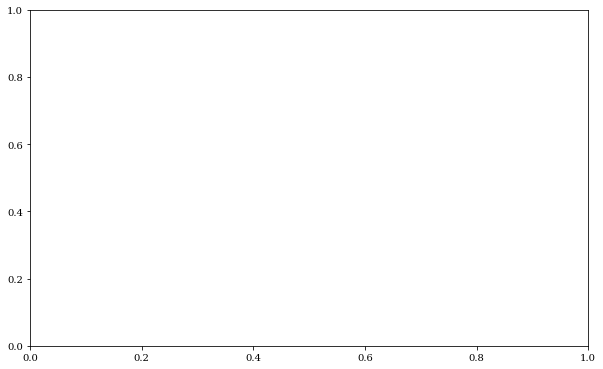

In [22]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [23]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccccccccc}
\toprule
 & $N=100$ & $N=200$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ & $N=7500$ & $N=10000$ & $N=25000$ & $N=50000$ & $N=75000$ & $N=100000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$151.18\%^{***}$\\ ($2.29\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$95.58\%^{***}$\\ ($1.69\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$43.90\%^{***}$\\ ($1.16\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$23.19\%^{***}$\\ ($0.86\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$4.34\%^{***}$\\ ($0.57\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.68\%^{*}$\\ ($0.41\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.41\%$\\ ($0.33\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.18\%$\\ ($0.28\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.05\%$\\ ($0.18\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.11\%$\\ ($0.13\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.14\%$\\ ($0.10\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.07\%$\\ ($0.09\%$)\

## Response STD

In [18]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.05)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

response_std_list = [0.5, 1, 2, 3, 4, 5]

In [19]:
response_std_result_dict = {response_std: None for response_std in response_std_list}

for response_std in response_std_list:
    print(f'\nResponse Standard Deviation = {response_std}')
    
    dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_std), UnivariateGaussian(0, std=response_std)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    response_std_result_dict[response_std] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Response Standard Deviation = 0.5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 1
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 2
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished


In [20]:
with open('results/ab_test_response_std.pkl', 'wb') as f:
    pickle.dump(response_std_result_dict, f)

with open('results/ab_test_response_std.pkl', 'rb') as f:
    response_std_result_dict = pickle.load(f)

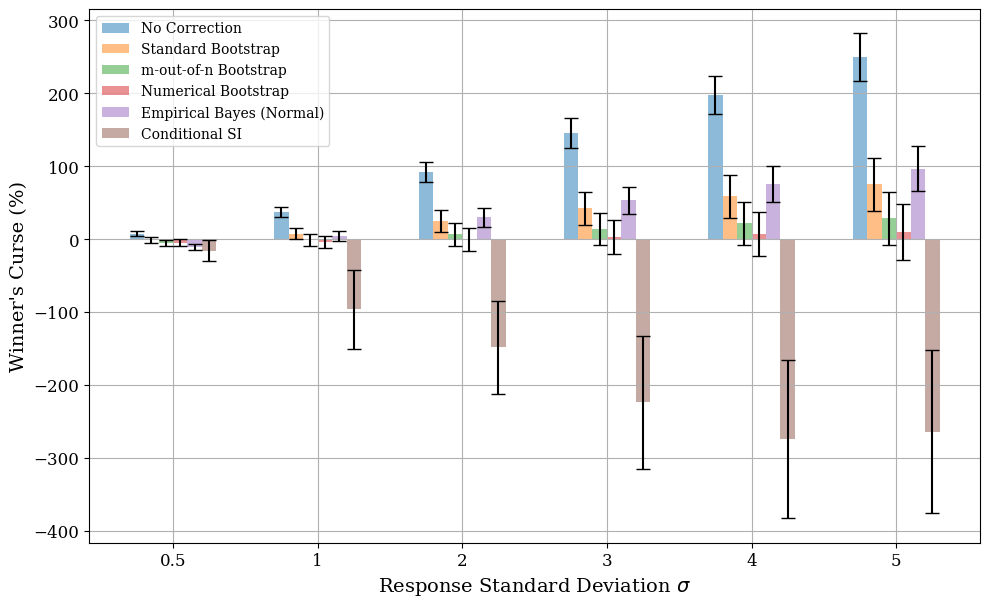

$\sigma=0.5$  $\sigma=1$  $\sigma=2$  \
No Correction            Mean            7.60       37.28       92.30   
                         Median          7.73       36.58       89.38   
                         S.E.            2.01        3.66        7.01   
Standard Bootstrap       Mean           -1.65        7.42       25.05   
                         Median          1.75        5.58       16.11   
                         S.E.            2.20        4.03        7.73   
m-out-of-n Bootstrap     Mean           -5.31       -1.56        6.32   
                         Median         -2.90       -3.47       -3.12   
                         S.E.            2.24        4.06        7.77   
Numerical Bootstrap      Mean           -5.09       -3.77       -0.24   
                         Median         -1.69       -8.08      -11.64   
                         S.E.            2.29        4.18        8.02   
Empirical Bayes (Normal) Mean          -10.84        4.12       29.78   
                         Median        -12.05        2.66       24.70   
                         S.E.            2.02        3.56        6.64   
Conditional SI           Mean          -15.75      -96.01     -148.50   
                         Median          1.38        2.38       -2.52   
                         S.E.            7.62       27.65       32.72   

                                 $\sigma=3$  $\sigma=4$  $\sigma=5$  
No Correction            Mean        145.17      197.63      249.24  
                         Median      141.64      193.21      241.51  
                         S.E.         10.28       13.53       16.81  
Standard Bootstrap       Mean         41.94       58.73       74.97  
                         Median       24.65       34.86       44.50  
                         S.E.         11.36       14.97       18.60  
m-out-of-n Bootstrap     Mean         13.84       21.33       28.19  
                         Median        0.16       -1.87       -6.23  
                         S.E.         11.42       15.04       18.68  
Numerical Bootstrap      Mean          3.17        6.63        9.55  
                         Median      -16.70      -26.05      -36.39  
                         S.E.         11.80       15.55       19.33  
Empirical Bayes (Normal) Mean         52.97       75.18       96.40  
                         Median       45.68       65.24       85.21  
                         S.E.          9.68       12.72       15.79  
Conditional SI           Mean       -224.00     -274.65     -264.30  
                         Median        9.75       10.97       20.19  
                         S.E.         46.45       55.36       56.93

In [21]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    data[response_std]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[response_std][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for response_std in response_std_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[response_std][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\sigma={}$'.format(p) for p in response_std_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(response_std_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in response_std_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in response_std_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(response_std_list)), labels=response_std_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [22]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    wc_mean = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[response_std][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[response_std]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[response_std][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[response_std][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$\sigma={response_std}$' for response_std in response_std_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(response_std_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $\sigma=0.5$ & $\sigma=1$ & $\sigma=2$ & $\sigma=3$ & $\sigma=4$ & $\sigma=5$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$7.60\%^{***}$\\ ($2.01\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$37.28\%^{***}$\\ ($3.66\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$92.30\%^{***}$\\ ($7.01\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$145.17\%^{***}$\\ ($10.28\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$197.63\%^{***}$\\ ($13.53\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$249.24\%^{***}$\\ ($16.81\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$-1.65\%$\\ ($2.20\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$7.42\%^{*}$\\ ($4.03\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$25.05\%^{***}$\\ ($7.73\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$41.94\%^{***}$\\ ($11.36\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$58.73\%^{***}$\\ ($14.97\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$74.97\%^{***}$\\ ($18.60\%$)

## $\Delta\tau / \sigma$

In [23]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    # }, 
}

ratio_list = [0.01, 0.1, 0.5, 1, 2]
# ratio_list = [0.1, 1.0]

samp_vol_list = [1, 2, 3]


In [24]:
ratio_result_dict = {}

for ratio in ratio_list:
    for samp_vol in samp_vol_list:
        delta_tau = round(samp_vol * ratio, 2)
        print(f'\nRatio = {ratio}; Sampling Volatility = {samp_vol}; Delta tau= {delta_tau}')

        response_vol = np.sqrt(data_params['sample_size'] / 2) * samp_vol

        dgp_params['base_effects'] = [PointMass(1), PointMass(1 + delta_tau)]
        dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_vol), UnivariateGaussian(0, std=response_vol)]

        result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=True, 
            n_jobs=-1
        )

        ratio_result_dict[(delta_tau, samp_vol, ratio)] = rct.calculate_winners_curse_measures(
            result_records=result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params
        )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Ratio = 0.01; Sampling Volatility = 1; Delta tau= 0.01
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Ratio = 0.01; Sampling Volatility = 2; Delta tau= 0.02
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Ratio = 2; Sampling Volatility = 2; Delta tau= 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   10.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Ratio = 2; Sampling Volatility = 3; Delta tau= 6
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    9.7s finished


In [25]:
with open('results/ab_test_ratio.pkl', 'wb') as f:
    pickle.dump(ratio_result_dict, f)

with open('results/ab_test_ratio.pkl', 'rb') as f:
    ratio_result_dict = pickle.load(f)

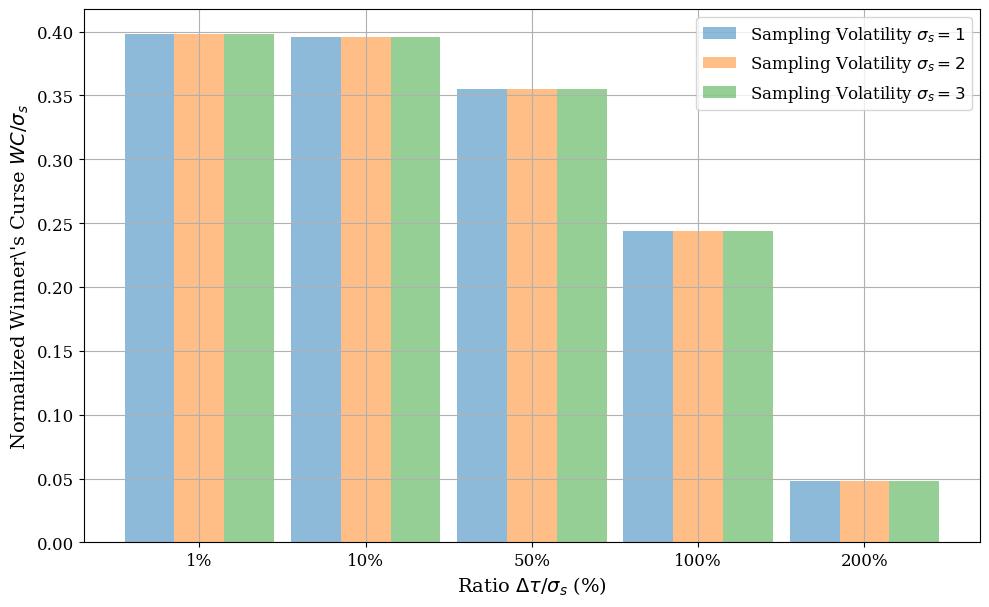

0.01  \
                                             $(\Delta\tau, \sigma_s) = (0.01, 1)$   
No Correction                         Mean                                 0.3978   
                                      Median                               0.3819   
                                      S.E.                                 0.0265   
Standard Bootstrap                    Mean                                 0.1198   
                                      Median                               0.0702   
                                      S.E.                                 0.0293   
m-out-of-n Bootstrap                  Mean                                 0.0457   
                                      Median                              -0.0065   
                                      S.E.                                 0.0294   
Numerical Bootstrap                   Mean                                 0.0161   
                                      Median                              -0.0363   
                                      S.E.                                 0.0304   
Empirical Bayes (Normal)              Mean                                 0.1569   
                                      Median                               0.1310   
                                      S.E.                                 0.0249   
Conditional SI\n(Andrews et al. 2024) Mean                                -0.1484   
                                      Median                               0.0733   
                                      S.E.                                 0.0523   

                                                                                   \
                                             $(\Delta\tau, \sigma_s) = (0.02, 2)$   
No Correction                         Mean                                 0.3978   
                                      Median                               0.3819   
                                      S.E.                                 0.0530   
Standard Bootstrap                    Mean                                 0.1198   
                                      Median                               0.0702   
                                      S.E.                                 0.0586   
m-out-of-n Bootstrap                  Mean                                 0.0457   
                                      Median                              -0.0065   
                                      S.E.                                 0.0588   
Numerical Bootstrap                   Mean                                 0.0161   
                                      Median                              -0.0363   
                                      S.E.                                 0.0609   
Empirical Bayes (Normal)              Mean                                 0.1569   
                                      Median                               0.1310   
                                      S.E.                                 0.0498   
Conditional SI\n(Andrews et al. 2024) Mean                                 0.0162   
                                      Median                               0.1129   
                                      S.E.                                 0.0818   

                                                                                   \
                                             $(\Delta\tau, \sigma_s) = (0.03, 3)$   
No Correction                         Mean                                 0.3978   
                                      Median                               0.3819   
                                      S.E.                                 0.0794   
Standard Bootstrap                    Mean                                 0.0939   
                                      Median                               0.0629   
                                      S.E.                                 0.080

In [26]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = ratio_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau, samp_vol, ratio = key

    data[(delta_tau, samp_vol)] = {}

    data[(delta_tau, samp_vol)]['No Correction'] = {
        'Mean': result_dict[key][f'{optimizer_key}_nc_wc_avg'] / samp_vol, 
        'Median': np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']) / samp_vol, 
        'S.E.': result_dict[key][f'{optimizer_key}_nc_wc_se'], 
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / samp_vol
        median_wc = np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr']) / samp_vol
        se_wc = result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[(delta_tau, samp_vol)][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (ratio, '$(\Delta\tau, \sigma_s) = ({}, {})$'.format(delta_tau, samp_vol))
    for delta_tau, samp_vol, ratio in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for delta_tau, samp_vol, _ in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[(delta_tau, samp_vol)][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(ratio_list))
bar_width = 0.3 * len(samp_vol_list)

for idx, samp_vol in enumerate(samp_vol_list):
    bar_values = [data[(dt, vol)]['No Correction']['Mean'] for dt, vol, _ in result_dict.keys() if vol == samp_vol]
    bar_errors = [1.96 * data[(dt, vol)]['No Correction']['S.E.'] for dt, vol, _ in result_dict.keys() if vol == samp_vol]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / len(samp_vol_list) + bar_width / 2 / len(samp_vol_list), 
        bar_values, 
        # yerr=bar_errors, 
        capsize=5, alpha=0.5, width=bar_width / len(samp_vol_list),
        label=r'Sampling Volatility $\sigma_s={}$'.format(samp_vol)
    )

ax.set_xlabel(r'Ratio $\Delta\tau / \sigma_s$ (%)', fontsize=axis_label_size)
ax.set_ylabel(r'Normalized Winner\'s Curse $WC / \sigma_s$', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(ratio_list)), 
    labels=[f'{item:.0%}' for item in ratio_list], 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=tick_label_size)
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(4)

In [27]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = ratio_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau, samp_vol, ratio = key

    data[(delta_tau, samp_vol)] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / samp_vol
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / samp_vol
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[key][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[(delta_tau, samp_vol)]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / samp_vol
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / samp_vol
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[(delta_tau, samp_vol)][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'{ratio:.2f}', '$(\Delta\\tau, \sigma_s) = ({:.2f}, {:.2f})$'.format(delta_tau, samp_vol))
    for delta_tau, samp_vol, ratio in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for delta_tau, samp_vol, _ in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[(delta_tau, samp_vol)][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)[['0.10', '1.00']]
print(latex_df.style.to_latex(
    column_format='c' * 2 * 3, 
    hrules=True
))


\begin{tabular}{cccccc}
\toprule
 & \multicolumn{3}{r}{0.10} & \multicolumn{3}{r}{1.00} \\
 & $(\Delta\tau, \sigma_s) = (0.10, 1.00)$ & $(\Delta\tau, \sigma_s) = (0.20, 2.00)$ & $(\Delta\tau, \sigma_s) = (0.30, 3.00)$ & $(\Delta\tau, \sigma_s) = (1.00, 1.00)$ & $(\Delta\tau, \sigma_s) = (2.00, 2.00)$ & $(\Delta\tau, \sigma_s) = (3.00, 3.00)$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$0.3959^{***}$\\ ($0.0265$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.3959^{***}$\\ ($0.0265$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.3959^{***}$\\ ($0.0265$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2442^{***}$\\ ($0.0306$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2442^{***}$\\ ($0.0306$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.2442^{***}$\\ ($0.0306$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.1189^{***}$\\ ($0.0294$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1189^{***}$\\ ($0.0294$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0895^{***}$\\ ($

## Noise distribution

In [18]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.025)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'plugin_correction': {
        'estimator': rct.plugin_correction_estimate, 
        'params': {}, 
        'display_name': 'Plugin Correction', 
    }, 
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    # }, 
}

noise_dstn_dict = {
    'Normal(0, 1)': UnivariateGaussian(0, std=1),
    'Uniform($-\sqrt{3}$, $-\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

In [19]:
noise_dstn_result_dict = {noise_dstn: None for noise_dstn in noise_dstn_dict.keys()}

for noise_key, noise_dstn in noise_dstn_dict.items():
    print(f'\nNoise Distribution = {noise_key}')
    
    dgp_params['noise_vars'] = [noise_dstn, noise_dstn]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    noise_dstn_result_dict[noise_key] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Distribution = Normal(0, 1)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution = Uniform($-\sqrt{3}$, $-\sqrt{3}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution = Laplace(0, $1/\sqrt{2}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution = Logistic(0, $\sqrt{3} / \pi$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.5s finished


In [20]:
with open('results/ab_test_noise_dstn.pkl', 'wb') as f:
    pickle.dump(noise_dstn_result_dict, f)

with open('results/ab_test_noise_dstn.pkl', 'rb') as f:
    noise_dstn_result_dict = pickle.load(f)

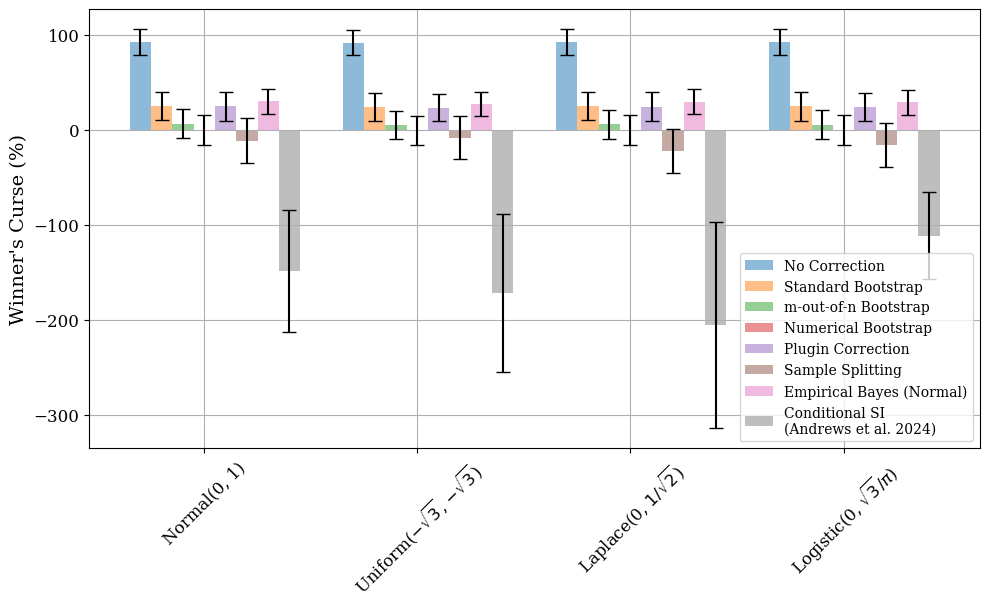

Normal(0, 1)  \
No Correction                         Mean           92.30   
                                      Median         89.38   
                                      S.E.            7.01   
Standard Bootstrap                    Mean           25.13   
                                      Median         16.82   
                                      S.E.            7.73   
m-out-of-n Bootstrap                  Mean            6.60   
                                      Median         -1.17   
                                      S.E.            7.77   
Numerical Bootstrap                   Mean            0.12   
                                      Median        -14.03   
                                      S.E.            8.03   
Plugin Correction                     Mean           24.57   
                                      Median         14.64   
                                      S.E.            7.71   
Sample Splitting                      Mean          -11.68   
                                      Median         -8.30   
                                      S.E.           12.03   
Empirical Bayes (Normal)              Mean           29.78   
                                      Median         24.70   
                                      S.E.            6.64   
Conditional SI\n(Andrews et al. 2024) Mean         -148.50   
                                      Median         -2.52   
                                      S.E.           32.72   
Sample Splitting                      Mean          -11.68   
                                      Median         -8.30   
                                      S.E.           12.03   

                                              Uniform($-\sqrt{3}$, $-\sqrt{3}$)  \
No Correction                         Mean                                91.46   
                                      Median                              91.37   
                                      S.E.                                 6.75   
Standard Bootstrap                    Mean                                24.23   
                                      Median                              18.52   
                                      S.E.                                 7.40   
m-out-of-n Bootstrap                  Mean                                 4.94   
                                      Median                               1.05   
                                      S.E.                                 7.44   
Numerical Bootstrap                   Mean                                -0.72   
                                      Median                              -5.40   
                                      S.E.                                 7.68   
Plugin Correction                     Mean                                23.39   
                                      Median                              18.73   
                                      S.E.                                 7.39   
Sample Splitting                      Mean                                -8.36   
                                      Median                              -6.16   
                                      S.E.                                11.50   
Empirical Bayes (Normal)              Mean                                27.09   
                                      Median                              26.63   
                                      S.E.                                 6.46   
Conditional SI\n(Andrews et al. 2024) Mean                              -172.01   
                                      Median                              12.33   
                                      S.E.                                42.53   
Sample Splitting                      Mean                                -8.36   
                                      Median                              -6.16   
                                      S.E.                          

In [21]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    data[noise_dstn]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[noise_dstn][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

    # sample splitting
    ss_wc_avg = 100 / delta_tau * np.mean(result_dict[noise_dstn]['rank_and_select_sample_splitting_val_est_arr'] - result_dict[noise_dstn]['rank_and_select_nc_val_true_arr'])
    ss_wc_se = 100 / delta_tau * np.std(result_dict[noise_dstn]['rank_and_select_sample_splitting_val_est_arr'] - result_dict[noise_dstn]['rank_and_select_nc_val_true_arr']) / np.sqrt(data_params['sample_size'])
    ss_wc_median = 100 / delta_tau * np.median(result_dict[noise_dstn]['rank_and_select_sample_splitting_val_est_arr'] - result_dict[noise_dstn]['rank_and_select_nc_val_true_arr'])
    data[noise_dstn]['Sample Splitting'] = {
        'Mean': ss_wc_avg, 'Median': ss_wc_median, 'S.E.': ss_wc_se
    }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names + ['Sample Splitting'], ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in noise_dstn_dict.keys():
    column_data = []
    for est_name in estimator_names + ['Sample Splitting']:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(noise_dstn_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(noise_dstn_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in noise_dstn_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in noise_dstn_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(noise_dstn_dict.keys())), 
    labels=noise_dstn_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [22]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean
# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    wc_mean = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[noise_dstn][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[noise_dstn]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[noise_dstn][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = list(noise_dstn_dict.keys())
print(latex_df.style.to_latex(
    column_format='c' * (len(noise_dstn_dict) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & Normal(0, 1) & Uniform($-\sqrt{3}$, $-\sqrt{3}$) & Laplace(0, $1/\sqrt{2}$) & Logistic(0, $\sqrt{3} / \pi$) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$92.30\%^{***}$\\ ($7.01\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$91.46\%^{***}$\\ ($6.75\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$92.48\%^{***}$\\ ($6.97\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$92.09\%^{***}$\\ ($6.93\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$25.13\%^{***}$\\ ($7.73\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$24.23\%^{***}$\\ ($7.40\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$25.06\%^{***}$\\ ($7.74\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$24.72\%^{***}$\\ ($7.67\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$6.60\%$\\ ($7.77\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$4.94\%$\\ ($7.44\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$5.95\%$\\ ($7.78\%$)\end{tabular} & \begin{tabular}[c]{@{}c

## Number of Treatments

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'response_type': 'continuous', 
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    # 'eb_tweedies': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'tweedies', 'dof': 3, 'bin_width': 0.2, 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Tweedies)'
    # }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
}

n_treatments_list = [2, 4, 6, 8, 10]
delta_tau = 0.0

In [16]:
n_treatments_result_dict = {n_treatments: None for n_treatments in n_treatments_list}

for n_treatments in n_treatments_list:
    print(f'\nNumber of Treatments = {n_treatments}')
    
    dgp_params['base_effects'] = [PointMass(1 + i * delta_tau) for i in range(n_treatments)]
    dgp_params['noise_vars'] = [UnivariateGaussian(0, std=1) for _ in range(n_treatments)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    n_treatments_result_dict[n_treatments] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Number of Treatments = 2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments = 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments = 6
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments = 8
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    9.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments = 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   11.4s finished


In [17]:
with open('results/ab_test_n_treatments.pkl', 'wb') as f:
    pickle.dump(n_treatments_result_dict, f)

with open('results/ab_test_n_treatments.pkl', 'rb') as f:
    n_treatments_result_dict = pickle.load(f)

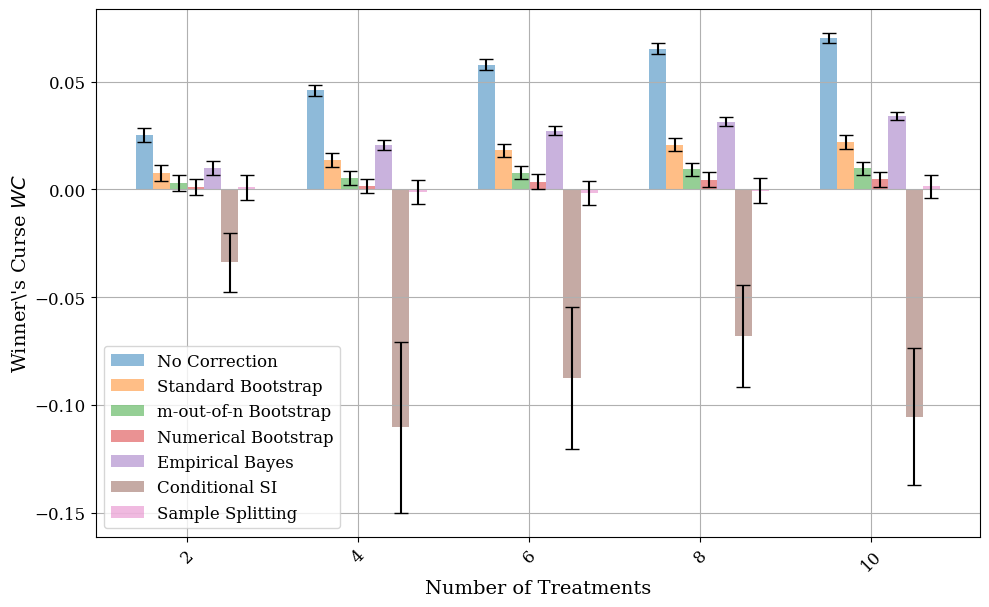

2       4       6       8       10
No Correction        Mean    0.0252  0.0459  0.0578  0.0653  0.0701
                     Median  0.0242  0.0431  0.0571  0.0640  0.0689
                     S.E.    0.0017  0.0013  0.0013  0.0012  0.0012
Standard Bootstrap   Mean    0.0076  0.0135  0.0180  0.0207  0.0220
                     Median  0.0044  0.0113  0.0151  0.0180  0.0188
                     S.E.    0.0019  0.0016  0.0016  0.0016  0.0016
m-out-of-n Bootstrap Mean    0.0029  0.0051  0.0077  0.0092  0.0097
                     Median -0.0002  0.0028  0.0046  0.0063  0.0078
                     S.E.    0.0019  0.0016  0.0016  0.0016  0.0016
Numerical Bootstrap  Mean    0.0010  0.0016  0.0035  0.0045  0.0046
                     Median -0.0023 -0.0010 -0.0004  0.0009  0.0018
                     S.E.    0.0019  0.0017  0.0018  0.0017  0.0017
Empirical Bayes      Mean    0.0099  0.0204  0.0273  0.0313  0.0340
                     Median  0.0083  0.0168  0.0252  0.0296  0.0329
                     S.E.    0.0016  0.0012  0.0011  0.0011  0.0010
Conditional SI       Mean   -0.0338 -0.1104 -0.0877 -0.0681 -0.1055
                     Median  0.0022 -0.0003  0.0059  0.0070  0.0002
                     S.E.    0.0070  0.0202  0.0168  0.0121  0.0163
Sample Splitting     Mean    0.0009 -0.0012 -0.0016 -0.0007  0.0013
                     Median  0.0024  0.0007 -0.0007 -0.0022 -0.0004
                     S.E.    0.0029  0.0028  0.0028  0.0030  0.0028

In [26]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = n_treatments_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each
for n_treatments in n_treatments_list:
    data[n_treatments] = {}

    data[n_treatments]['No Correction'] = {
        'Mean': result_dict[n_treatments][f'{optimizer_key}_nc_wc_avg'],
        'Median': np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': result_dict[n_treatments][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[n_treatments][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for n_treatments in n_treatments_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[n_treatments][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=n_treatments_list
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(n_treatments_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in n_treatments_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in n_treatments_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel(r'Winner\'s Curse $WC$', fontsize=axis_label_size)
ax.set_xlabel('Number of Treatments', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(n_treatments_list)), 
    labels=n_treatments_list, 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=tick_label_size)
ax.grid()
plt.tight_layout()
plt.savefig('figures/rct_n_treatments.png')
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(4)

In [22]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = n_treatments_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for n_treatments in n_treatments_list:
    data[n_treatments] = {}

    wc_mean = result_dict[n_treatments][f'{optimizer_key}_nc_wc_avg']
    wc_se = result_dict[n_treatments][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[n_treatments][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[n_treatments]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[n_treatments][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [n_treatments for n_treatments in n_treatments_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(n_treatments_list) + 1), 
    hrules=True
))

\begin{tabular}{cccccc}
\toprule
 & 2 & 4 & 6 & 8 & 10 \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$0.0252^{***}$\\ ($0.0017$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0459^{***}$\\ ($0.0013$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0578^{***}$\\ ($0.0013$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0653^{***}$\\ ($0.0012$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0701^{***}$\\ ($0.0012$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.0076^{***}$\\ ($0.0019$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0135^{***}$\\ ($0.0016$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0180^{***}$\\ ($0.0016$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0207^{***}$\\ ($0.0016$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0220^{***}$\\ ($0.0016$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.0029$\\ ($0.0019$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0051^{***}$\\ ($0.0016$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0077^{*

# Bernoulli Response

In [23]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'plugin_correction': {
        'estimator': rct.plugin_correction_estimate, 
        'params': {}, 
        'display_name': 'Plugin Correction', 
    }, 
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Spike-Slab)'
    }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI\n(Andrews et al. 2024)'
    }, 
    'hybrid_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Hybrid SI\n(Andrews et al. 2024)'
    }, 
}
bernoulli_te_list = [
    # (0.1, 0.11), (0.2, 0.21), (0.3, 0.31), (0.1, 0.15), (0.2, 0.25), (0.3, 0.35)
    (0.1, 0.105), (0.2, 0.205), (0.3, 0.305), (0.1, 0.11), (0.2, 0.21), (0.3, 0.31)
]

In [ ]:
bernoulli_te_result_dict = {bernoulli_te: None for bernoulli_te in bernoulli_te_list}

for te_tuple in bernoulli_te_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effects'] = [PointMass(te_tuple[0]), PointMass(te_tuple[1])]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_te_result_dict[te_tuple] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params, 
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


(tau_1, tau_2)= (0.1, 0.105)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    5.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.2, 0.205)
Running 500 experiments...


In [40]:
with open('results/ab_test_bernoulli_delta_tau.pkl', 'wb') as f:
    pickle.dump(bernoulli_te_result_dict, f)

with open('results/ab_test_bernoulli_delta_tau.pkl', 'rb') as f:
    bernoulli_te_result_dict = pickle.load(f)

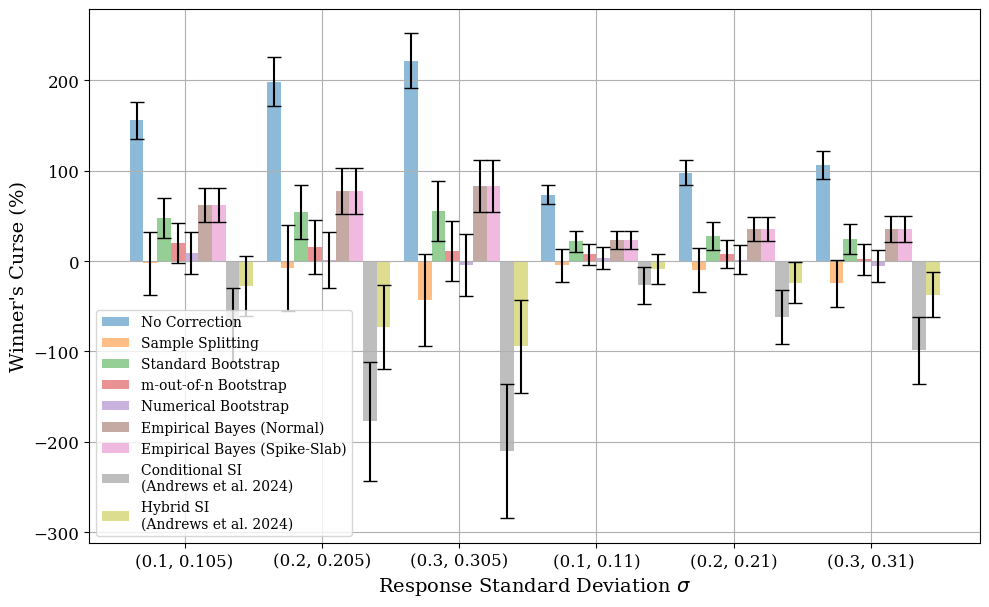

$\Delta\tau = 0.005$  \
                                             $(\tau_1, \tau_2)$ = (0.1, 0.105)   
No Correction                         Mean                              155.68   
                                      Median                            140.00   
                                      S.E.                               10.43   
Sample Splitting                      Mean                               -2.64   
                                      Median                            -20.00   
                                      S.E.                               17.77   
Standard Bootstrap                    Mean                               47.83   
                                      Median                             32.80   
                                      S.E.                               11.41   
m-out-of-n Bootstrap                  Mean                               19.84   
                                      Median                              5.20   
                                      S.E.                               11.45   
Numerical Bootstrap                   Mean                                9.15   
                                      Median                             -7.05   
                                      S.E.                               11.78   
Empirical Bayes (Normal)              Mean                               62.05   
                                      Median                             51.17   
                                      S.E.                                9.67   
Empirical Bayes (Spike-Slab)          Mean                               62.04   
                                      Median                             51.15   
                                      S.E.                                9.67   
Conditional SI\n(Andrews et al. 2024) Mean                              -70.72   
                                      Median                             27.73   
                                      S.E.                               20.82   
Hybrid SI\n(Andrews et al. 2024)      Mean                              -27.32   
                                      Median                             31.10   
                                      S.E.                               16.87   

                                                                                \
                                             $(\tau_1, \tau_2)$ = (0.2, 0.205)   
No Correction                         Mean                              198.52   
                                      Median                            180.00   
                                      S.E.                               13.85   
Sample Splitting                      Mean                               -7.64   
                                      Median                            -20.00   
                                      S.E.                               24.04   
Standard Bootstrap                    Mean                               54.28   
                                      Median                             38.44   
                                      S.E.                               15.21   
m-out-of-n Bootstrap                  Mean                               15.65   
                                      Median                             -2.03   
                                      S.E.                               15.22   
Numerical Bootstrap                   Mean                                1.14   
                                      Median                            -13.98   
                                      S.E.                               15.69   
Empirical Bayes (Normal)              Mean                               77.64   
                                      Median                             61.20   
                                      S.E.                               12.91   
Empirical Bayes (Spike-Slab)          M

In [41]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\tau = {np.round(key[1] - key[0], 4)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(bernoulli_te_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in bernoulli_te_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in bernoulli_te_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(bernoulli_te_list)), labels=bernoulli_te_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [42]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se']/ delta_tau * 100

    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[key][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[key]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / delta_tau * 100
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / delta_tau * 100
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[key][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\\tau = {np.round(key[1] - key[0], 4)}$', '$(\\tau_1, \\tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[key][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)[['$\Delta\\tau = 0.005$', '$\Delta\\tau = 0.01$']]
print(latex_df.style.to_latex(
    column_format='c' * (2 * 3 + 1), 
    hrules=True
))


\begin{tabular}{ccccccc}
\toprule
 & \multicolumn{3}{r}{$\Delta\tau = 0.005$} & \multicolumn{3}{r}{$\Delta\tau = 0.01$} \\
 & $(\tau_1, \tau_2)$ = (0.1, 0.105) & $(\tau_1, \tau_2)$ = (0.2, 0.205) & $(\tau_1, \tau_2)$ = (0.3, 0.305) & $(\tau_1, \tau_2)$ = (0.1, 0.11) & $(\tau_1, \tau_2)$ = (0.2, 0.21) & $(\tau_1, \tau_2)$ = (0.3, 0.31) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$155.68\%^{***}$\\ ($10.43$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$198.52\%^{***}$\\ ($13.85$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$221.48\%^{***}$\\ ($15.55$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$73.52\%^{***}$\\ ($5.46$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$97.68\%^{***}$\\ ($7.10$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$105.96\%^{***}$\\ ($7.83$)\%\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$-2.64\%$\\ ($17.77$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-7.64\%$\\ ($24.04$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-43.08\%^{*}$\\ ($26.0

In [43]:
optimizer_key = 'rank_and_select'
wc_measures_dict = bernoulli_te_result_dict[(0.3, 0.31)]


nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
clairvoyant_val = 0.31
policy_comp_dict = {
    'Clairvoyant Policy': {'Policy Value': f"{clairvoyant_val:.4f}"}, 
    'Focal Policy': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"},
}

ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
random_val = 0.305
policy_comp_dict.update({
    'Sample Splitting': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"}, 
    'Random Guessing': {'Policy Value': f'{random_val:.4f}'},
})

policy_comp_df = pd.DataFrame(policy_comp_dict).T
policy_comp_df
# print(policy_comp_df.style.to_latex(
#     column_format='cc',  
#     hrules=True
# ))

,Policy Value
Clairvoyant Policy,0.3100
Focal Policy,\begin{tabular}[c]{@{}c@{}}$0.3062$\\ ($0.0002...
Sample Splitting,\begin{tabular}[c]{@{}c@{}}$0.3056$\\ ($0.0002...
Random Guessing,0.3050


## Sample Size

In [36]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.105)],
    'response_type': 'bernoulli',
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

sample_size_list = [100, 1000, 2500, 5000, 10000, 50000]


In [ ]:
bernoulli_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


Sample Size = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s


In [101]:
with open('results/ab_test_bernoulli_sample_size.pkl', 'wb') as f:
    pickle.dump(bernoulli_sample_size_result_dict, f)

with open('results/ab_test_bernoulli_sample_size.pkl', 'rb') as f:
    bernoulli_sample_size_result_dict = pickle.load(f)

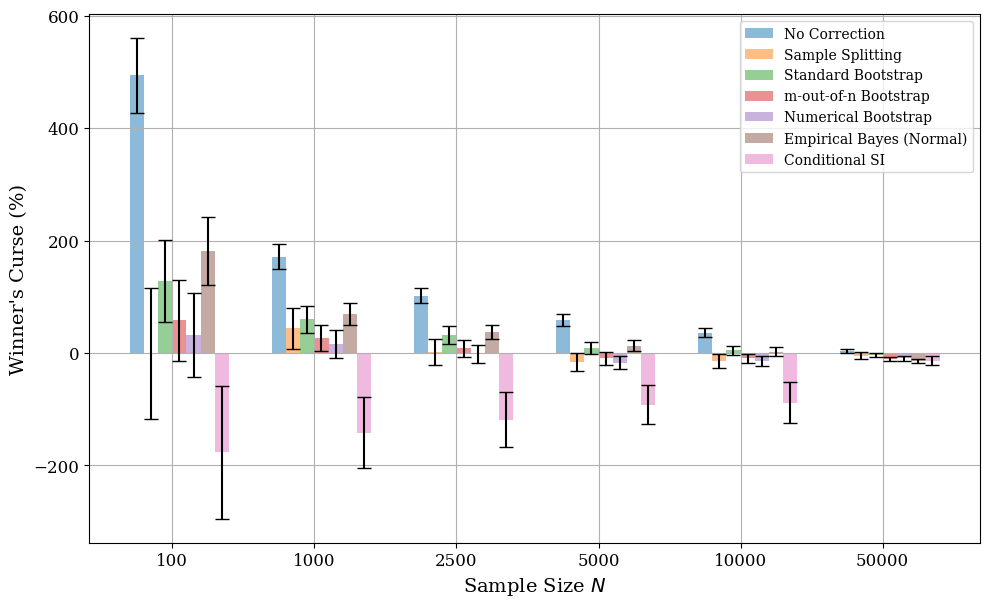

$N=100$  $N=1000$  $N=2500$  $N=5000$  \
No Correction            Mean     493.60    171.52    101.99     58.38   
                         Median   500.00    180.00    104.00     60.00   
                         S.E.      33.78     10.98      7.15      5.17   
Sample Splitting         Mean      -0.40     43.68      1.22    -15.95   
                         Median  -100.00     40.00    -10.00    -12.00   
                         S.E.      59.45     18.31     11.90      8.37   
Standard Bootstrap       Mean     128.06     59.80     32.21      8.77   
                         Median   106.00     58.38     29.17      9.04   
                         S.E.      37.27     12.13      7.88      5.63   
m-out-of-n Bootstrap     Mean      57.95     26.50      8.30     -9.58   
                         Median    33.90     17.35      4.16    -13.12   
                         S.E.      37.07     12.16      7.94      5.67   
Numerical Bootstrap      Mean      32.02     15.69     -1.55    -17.77   
                         Median     6.10      3.52     -4.76    -26.59   
                         S.E.      38.33     12.69      8.30      5.95   
Empirical Bayes (Normal) Mean     180.74     69.37     37.17     13.11   
                         Median   173.58     72.92     37.01     11.51   
                         S.E.      30.99     10.30      6.76      5.01   
Conditional SI           Mean    -177.08   -141.54   -118.44    -92.15   
                         Median    87.13     36.44     13.27    -13.75   
                         S.E.      60.08     32.12     24.99     17.61   

                                 $N=10000$  $N=50000$  
No Correction            Mean        36.24       3.65  
                         Median      32.00       4.40  
                         S.E.         3.87       1.81  
Sample Splitting         Mean       -14.87      -4.62  
                         Median     -20.00      -4.80  
                         S.E.         6.45       2.95  
Standard Bootstrap       Mean         4.45      -4.07  
                         Median      -1.88      -1.41  
                         S.E.         4.21       1.97  
m-out-of-n Bootstrap     Mean        -9.71     -10.34  
                         Median     -18.13      -8.42  
                         S.E.         4.26       2.05  
Numerical Bootstrap      Mean       -14.24      -9.76  
                         Median     -23.44      -7.07  
                         S.E.         4.49       2.13  
Empirical Bayes (Normal) Mean         2.48     -13.65  
                         Median      -0.90     -14.30  
                         S.E.         3.78       1.83  
Conditional SI           Mean       -88.30     -13.58  
                         Median      -7.78      -0.04  
                         S.E.        18.45       4.43

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $N=100$ & $N=1000$ & $N=2500$ & $N=5000$ & $N=10000$ & $N=50000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$493.60\%^{***}$\\ ($33.78\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$171.52\%^{***}$\\ ($10.98\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$101.99\%^{***}$\\ ($7.15\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$58.38\%^{***}$\\ ($5.17\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$36.24\%^{***}$\\ ($3.87\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$3.65\%^{**}$\\ ($1.81\%$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$-0.40\%$\\ ($59.45\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$43.68\%^{**}$\\ ($18.31\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.22\%$\\ ($11.90\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-15.95\%^{*}$\\ ($8.37\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-14.87\%^{**}$\\ ($6.45\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-4.62\%$\\ ($2.95\%$)\end{tabular} \\
Standard Boo

# Logit Response

In [49]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'response_type': 'logit', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

logit_te_list = [
    (0.1, 0.11), (0.2, 0.21), (0.3, 0.31), (0.1, 0.15), (0.2, 0.25), (0.3, 0.35)
]

In [50]:
logit_te_result_dict = {logit_te: None for logit_te in logit_te_list}

for te_tuple in logit_te_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effects'] = [PointMass(te_tuple[0]),PointMass(te_tuple[1])]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    logit_te_result_dict[te_tuple] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params, 
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


(tau_1, tau_2)= (0.1, 0.11)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   26.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   32.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.2, 0.21)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   24.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   31.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.3, 0.31)
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   24.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   31.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.2, 0.25)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   25.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   32.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.3, 0.35)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   25.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   32.3s finished


In [51]:
with open('results/ab_test_logit_delta_tau.pkl', 'wb') as f:
    pickle.dump(logit_te_result_dict, f)

with open('results/ab_test_logit_delta_tau.pkl', 'rb') as f:
    logit_te_result_dict = pickle.load(f)

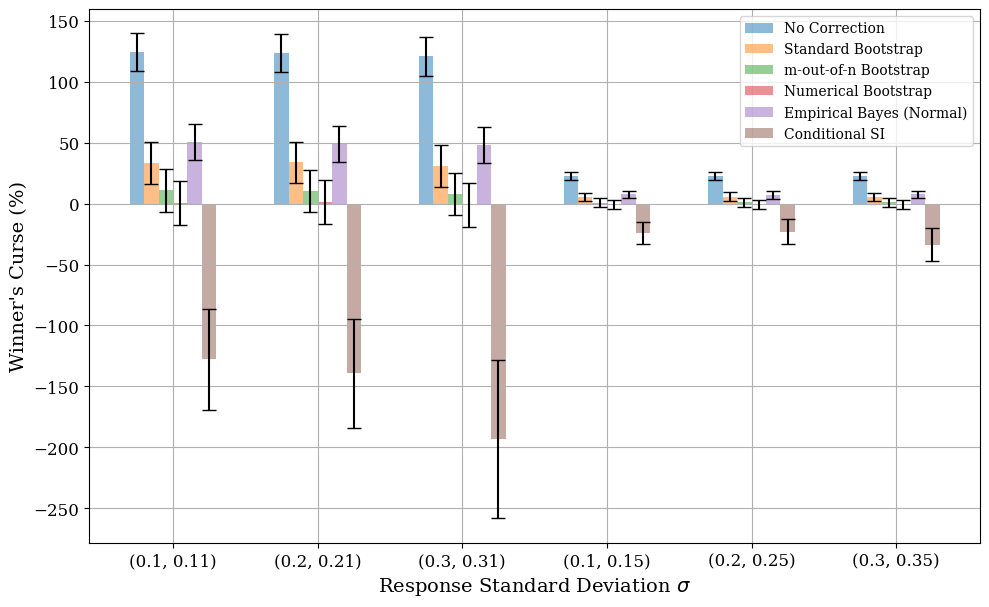

$\Delta\tau = 0.01$  \
                                $(\tau_1, \tau_2)$ = (0.1, 0.11)   
No Correction            Mean                             124.24   
                         Median                           110.21   
                         S.E.                               7.99   
Standard Bootstrap       Mean                              33.26   
                         Median                            24.32   
                         S.E.                               8.80   
m-out-of-n Bootstrap     Mean                              10.89   
                         Median                             2.45   
                         S.E.                               8.90   
Numerical Bootstrap      Mean                               0.26   
                         Median                            -9.02   
                         S.E.                               9.17   
Empirical Bayes (Normal) Mean                              50.60   
                         Median                            40.90   
                         S.E.                               7.55   
Conditional SI           Mean                            -127.89   
                         Median                           -11.51   
                         S.E.                              21.11   

                                                                  \
                                $(\tau_1, \tau_2)$ = (0.2, 0.21)   
No Correction            Mean                             123.49   
                         Median                           116.92   
                         S.E.                               7.89   
Standard Bootstrap       Mean                              33.88   
                         Median                            21.31   
                         S.E.                               8.69   
m-out-of-n Bootstrap     Mean                              10.74   
                         Median                            -6.09   
                         S.E.                               8.78   
Numerical Bootstrap      Mean                               1.32   
                         Median                           -15.48   
                         S.E.                               9.05   
Empirical Bayes (Normal) Mean                              49.15   
                         Median                            38.47   
                         S.E.                               7.44   
Conditional SI           Mean                            -139.40   
                         Median                           -10.88   
                         S.E.                              22.67   

                                                                  \
                                $(\tau_1, \tau_2)$ = (0.3, 0.31)   
No Correction            Mean                             120.84   
                         Median                           115.57   
                         S.E.                               8.04   
Standard Bootstrap       Mean                              30.98   
                         Median                            23.33   
                         S.E.                               8.88   
m-out-of-n Bootstrap     Mean                               8.01   
                         Median                             0.92   
                         S.E.                               8.96   
Numerical Bootstrap      Mean                              -1.43   
                         Median                           -14.36   
                         S.E.                               9.23   
Empirical Bayes (Normal) Mean                              48.14   
                         Median                            45.44   
                         S.E.                               7.58   
Conditional SI           Mean                            -193.60   
                         Median                           -18.43   
                         S.E.  

In [52]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(logit_te_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in logit_te_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in logit_te_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(logit_te_list)), labels=logit_te_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [53]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / delta_tau * 100
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[key][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[key]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / delta_tau * 100
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / delta_tau * 100
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[key][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\\tau = {np.round(key[1] - key[0], 2)}$', '$(\\tau_1, \\tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[key][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)[['$\Delta\\tau = 0.01$', '$\Delta\\tau = 0.05$']]
print(latex_df.style.to_latex(
    column_format='c' * (2 * 3 + 1), 
    hrules=True
))


\begin{tabular}{ccccccc}
\toprule
 & \multicolumn{3}{r}{$\Delta\tau = 0.01$} & \multicolumn{3}{r}{$\Delta\tau = 0.05$} \\
 & $(\tau_1, \tau_2)$ = (0.1, 0.11) & $(\tau_1, \tau_2)$ = (0.2, 0.21) & $(\tau_1, \tau_2)$ = (0.3, 0.31) & $(\tau_1, \tau_2)$ = (0.1, 0.15) & $(\tau_1, \tau_2)$ = (0.2, 0.25) & $(\tau_1, \tau_2)$ = (0.3, 0.35) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$124.24\%^{***}$\\ ($7.99$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$123.49\%^{***}$\\ ($7.89$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$120.84\%^{***}$\\ ($8.04$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$22.89\%^{***}$\\ ($1.65$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$22.94\%^{***}$\\ ($1.64$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$22.69\%^{***}$\\ ($1.65$)\%\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$33.26\%^{***}$\\ ($8.80$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$33.88\%^{***}$\\ ($8.69$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$30.98\%^{***}$\\ (

## Sample Size

In [54]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(np.log(1 / 9)), PointMass(np.log(11 / 89))],
    'response_type': 'logit',
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'eb_normal': {
        'estimator': rct.empirical_bayes_estimate,
        'params': {'prior': 'normal', 'prior_orientation': 'treatment'},
        'display_name': 'Empirical Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate,
    #     'params': {'prior': 'spike_slab', 'prior_orientation': 'treatment'},
    #     'display_name': 'Empirical Bayes (Spike-Slab)'
    # }, 
    'conditional_si': {
        'estimator': rct.selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': rct.selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

sample_size_list = [50, 100, 500, 1000, 2500, 5000]

In [55]:
logit_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    logit_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   28.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   36.0s finished
c:\Users\xusik\Desktop\research\winners-curse\core\rct.py:482: RuntimeWarning: Mean of empty slice
  f'{optimizer}_{estimator}_val_est_avg': np.nanmean(temp_val_est_arr),
c:\Users\xusik\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\xusik\Desktop\research\winners-curse\core\rct.py:484: RuntimeWarning: Mean of empty slice
  f'{optimizer}_{estimator}_wc_avg': np.nanmean(temp_wc_arr),
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   25.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   32.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   15.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   40.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   51.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 2500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   25.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   41.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  2.2min finished


In [56]:
with open('results/ab_test_logit_sample_size.pkl', 'wb') as f:
    pickle.dump(logit_sample_size_result_dict, f)

with open('results/ab_test_logit_sample_size.pkl', 'rb') as f:
    logit_sample_size_result_dict = pickle.load(f)

c:\Users\xusik\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


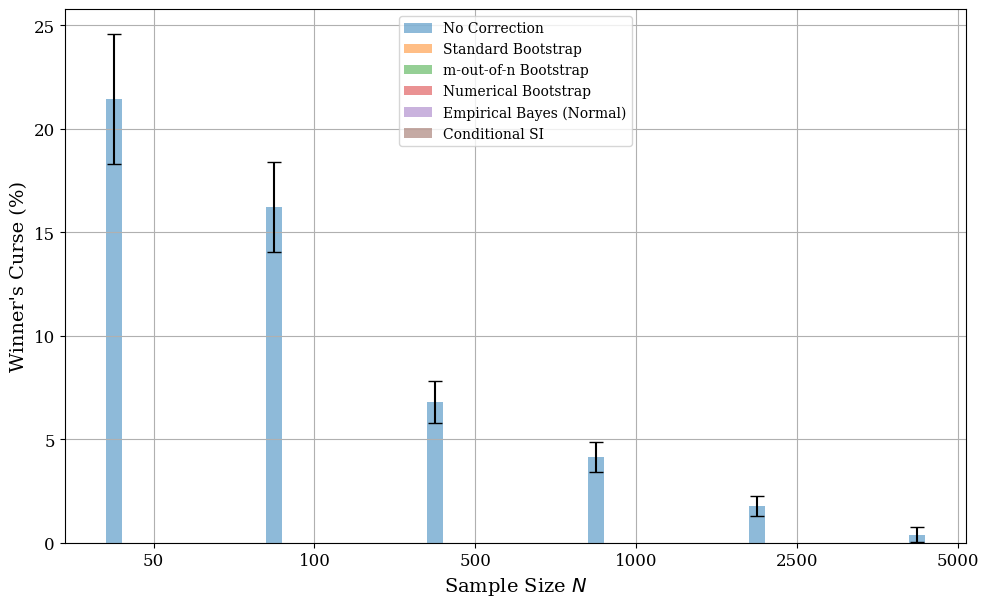

$N=50$  $N=100$  $N=500$  $N=1000$  $N=2500$  \
No Correction            Mean     21.43    16.21     6.79      4.16      1.76   
                         Median   18.78    14.09     5.63      3.76      1.88   
                         S.E.      1.60     1.11     0.52      0.37      0.25   
Standard Bootstrap       Mean       NaN      NaN      NaN       NaN       NaN   
                         Median     NaN      NaN      NaN       NaN       NaN   
                         S.E.       NaN      NaN      NaN       NaN       NaN   
m-out-of-n Bootstrap     Mean       NaN      NaN      NaN       NaN       NaN   
                         Median     NaN      NaN      NaN       NaN       NaN   
                         S.E.       NaN      NaN      NaN       NaN       NaN   
Numerical Bootstrap      Mean       NaN      NaN      NaN       NaN       NaN   
                         Median     NaN      NaN      NaN       NaN       NaN   
                         S.E.       NaN      NaN      NaN       NaN       NaN   
Empirical Bayes (Normal) Mean       NaN      NaN      NaN       NaN       NaN   
                         Median     NaN      NaN      NaN       NaN       NaN   
                         S.E.       NaN      NaN      NaN       NaN       NaN   
Conditional SI           Mean       NaN      NaN      NaN       NaN       NaN   
                         Median     NaN      NaN      NaN       NaN       NaN   
                         S.E.       NaN      NaN      NaN       NaN       NaN   

                                 $N=5000$  
No Correction            Mean        0.38  
                         Median      0.19  
                         S.E.        0.19  
Standard Bootstrap       Mean         NaN  
                         Median       NaN  
                         S.E.         NaN  
m-out-of-n Bootstrap     Mean         NaN  
                         Median       NaN  
                         S.E.         NaN  
Numerical Bootstrap      Mean         NaN  
                         Median       NaN  
                         S.E.         NaN  
Empirical Bayes (Normal) Mean         NaN  
                         Median       NaN  
                         S.E.         NaN  
Conditional SI           Mean         NaN  
                         Median       NaN  
                         S.E.         NaN

In [57]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [58]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = logit_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level_with_p_val(ttest_1samp(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr'], 0)[1])
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level_with_p_val(ttest_1samp(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'], 0)[1])
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $N=50$ & $N=100$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$21.43\%^{***}$\\ ($1.60\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$16.21\%^{***}$\\ ($1.11\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$6.79\%^{***}$\\ ($0.52\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$4.16\%^{***}$\\ ($0.37\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.76\%^{***}$\\ ($0.25\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.38\%^{**}$\\ ($0.19\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$nan\%$\\ ($nan\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$nan\%$\\

c:\Users\xusik\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\xusik\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


# Sample Size

## Signal-to-Noise Ratio

In [244]:
# bernoulli specification
ber_dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), None],
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

# continuous specification
cont_dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), None],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'response_type': 'continuous', 
    'dgp_seed': 0
}

# # logit specification
# log_dgp_params = {
#     'n_experiments': 1, 
#     'base_effects': [PointMass(np.log(1 / 9)), PointMass(np.log(11 / 89))],
#     'response_type': 'logit', 
#     'dgp_seed': 0
# }

optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 5000}

estimators_dict = {}

delta_tau_list = [(0.003, 0.01), (0.0045, 0.025), (0.015, 0.05)]
sample_size_list = [100, 1000, 2500, 5000, 10000, 50000, 100000, 200000]

In [245]:
ber_sample_size_result_dict = {}
cont_sample_size_result_dict = {}

for delta_tau_tup in delta_tau_list:
    for sample_size in sample_size_list:
        print(f'\nDelta Tau = {delta_tau_tup}, Sample Size = {sample_size}')
        data_params['sample_size'] = sample_size
        ber_dgp_params['base_effects'][1] = PointMass(0.1 + delta_tau_tup[0])
        cont_dgp_params['base_effects'][1] = PointMass(1 + delta_tau_tup[1])

        cont_result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=cont_dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=True, 
            n_jobs=-1
        )
        cont_sample_size_result_dict[(delta_tau_tup[1], sample_size)] = rct.calculate_winners_curse_measures(
            result_records=cont_result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params,
        )

        ber_result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=ber_dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=True, 
            n_jobs=-1
        )
        ber_sample_size_result_dict[(delta_tau_tup[0], sample_size)] = rct.calculate_winners_curse_measures(
            result_records=ber_result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params,
        )


Delta Tau = (0.003, 0.01), Sample Size = 100
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4038 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4009 tasks      | elapsed:    0.1s


Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4009 tasks      | elapsed:    0.1s



Delta Tau = (0.003, 0.01), Sample Size = 1000
Running 5000 experiments...


...

[Parallel(n_jobs=-1)]: Done 3661 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    0.7s finished



Delta Tau = (0.015, 0.05), Sample Size = 200000
Running 5000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 2000 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 4674 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    4.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s


Running 5000 experiments...


[Parallel(n_jobs=-1)]: Done 3040 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 4800 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    1.9s finished


In [246]:
cont_result_records = [
    {
        'delta_tau': delta_tau, 
        'sample_size': sample_size, 
        'p_val': ttest_1samp(result_dict[f'{optimizer_key}_nc_wc_arr'], 0)[1],
        'wc_avg': result_dict[f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100,
        'wc_se': result_dict[f'{optimizer_key}_nc_wc_arr'].std() / result_dict[f'{optimizer_key}_nc_wc_arr'].shape[0] ** 0.5 / delta_tau * 100,
    }
    for (delta_tau, sample_size), result_dict in cont_sample_size_result_dict.items()
]

wc_df = pd.DataFrame(cont_result_records)
def aggregate_result(avg, se, p_val) -> float:
    sig_level = significance_level_with_p_val(p_val)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    return "\\begin{tabular}[c]{@{}c@{}}" + f"${avg:.2f}\%" + sig_level + f"$\\\\ (${se:.2f}\%$)" + "\end{tabular}"
wc_df['wc'] = wc_df.apply(lambda x: aggregate_result(x['wc_avg'], x['wc_se'], x['p_val']), axis=1)
wc_df = wc_df.pivot(index='sample_size', columns='delta_tau', values='wc')

# delete names for the index column 
wc_df.index.name = None
wc_df.columns.name = None

wc_df.columns = [
    f'$\\Delta\\tau / \\sigma$ = {delta_tau/1 * 100:.1f}\%' for delta_tau in wc_df.columns
]
wc_df.index = [
    f'$N = {sample_size}$' for sample_size in wc_df.index
]

print(wc_df.style.to_latex(
    column_format='c' * (len(delta_tau_list) + 1), 
    hrules=True
))


\begin{tabular}{cccc}
\toprule
 & $\Delta\tau / \sigma$ = 1.0\% & $\Delta\tau / \sigma$ = 2.5\% & $\Delta\tau / \sigma$ = 5.0\% \\
\midrule
$N = 100$ & \begin{tabular}[c]{@{}c@{}}$575.40\%^{***}$\\ ($11.75\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$227.15\%^{***}$\\ ($4.73\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$108.41\%^{***}$\\ ($2.41\%$)\end{tabular} \\
$N = 1000$ & \begin{tabular}[c]{@{}c@{}}$178.92\%^{***}$\\ ($3.74\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$63.50\%^{***}$\\ ($1.57\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$19.91\%^{***}$\\ ($0.86\%$)\end{tabular} \\
$N = 2500$ & \begin{tabular}[c]{@{}c@{}}$110.79\%^{***}$\\ ($2.43\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$32.04\%^{***}$\\ ($1.05\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$5.94\%^{***}$\\ ($0.57\%$)\end{tabular} \\
$N = 5000$ & \begin{tabular}[c]{@{}c@{}}$72.65\%^{***}$\\ ($1.72\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$14.53\%^{***}$\\ ($0.78\%$)\end{tabular} & \begin{tabular}[c]{@

## Number of Treatments

In [8]:
# continuous specification
cont_dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'response_type': 'continuous', 
    'dgp_seed': 0
}

# # logit specification
# log_dgp_params = {
#     'n_experiments': 1, 
#     'base_effects': [PointMass(np.log(1 / 9)), PointMass(np.log(11 / 89))],
#     'response_type': 'logit', 
#     'dgp_seed': 0
# }

optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {}

delta_tau = 0.0 
n_treatments_list = [2, 4, 6, 8, 10]
sample_size_list = [10000, 25000, 50000, 100000, 250000, 500000]

In [9]:
cont_sample_size_result_dict = {}

for n_treatments in n_treatments_list:
    for sample_size in sample_size_list:
        print(f'\nNumber of Treatments = {n_treatments}, Sample Size = {sample_size}')
        data_params['sample_size'] = sample_size
        cont_dgp_params['base_effects'] = [PointMass(1 + delta_tau * i) for i in range(n_treatments)]
        cont_dgp_params['noise_vars'] = [UnivariateGaussian(0, std=1) for i in range(n_treatments)]

        cont_result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=cont_dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=True, 
            n_jobs=-1
        )
        cont_sample_size_result_dict[(n_treatments, sample_size)] = rct.calculate_winners_curse_measures(
            result_records=cont_result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params,
        )


Number of Treatments = 2, Sample Size = 10000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    3.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Number of Treatments = 2, Sample Size = 25000
Running 500 experiments...

Number of Treatments = 2, Sample Size = 50000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s



Number of Treatments = 2, Sample Size = 100000
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 481 out of 500 | elapsed:    1.3s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    1.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Number of Treatments = 10, Sample Size = 250000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    3.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Number of Treatments = 10, Sample Size = 500000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.5s finished


In [10]:
with open('results/ab_test_n_treatments_sample_size.pkl', 'wb') as f:
    pickle.dump(cont_sample_size_result_dict, f)

with open('results/ab_test_n_treatments_sample_size.pkl', 'rb') as f:
    cont_sample_size_result_dict = pickle.load(f)

In [12]:
optimizer_key = 'rank_and_select'

cont_result_records = [
    {
        'n_treatments': n_treatments, 
        'sample_size': sample_size, 
        'p_val': ttest_1samp(result_dict[f'{optimizer_key}_nc_wc_arr'], 0)[1],
        'wc_avg': result_dict[f'{optimizer_key}_nc_wc_avg'],
        'wc_se': result_dict[f'{optimizer_key}_nc_wc_se'],
    }
    for (n_treatments, sample_size), result_dict in cont_sample_size_result_dict.items()
]

wc_df = pd.DataFrame(cont_result_records)
def aggregate_result(avg, se, p_val) -> float:
    sig_level = significance_level_with_p_val(p_val)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    return "\\begin{tabular}[c]{@{}c@{}}" + f"${avg:.4f}" + sig_level + f"$\\\\ (${se:.4f}$)" + "\end{tabular}"
wc_df['wc'] = wc_df.apply(lambda x: aggregate_result(x['wc_avg'], x['wc_se'], x['p_val']), axis=1)
wc_df = wc_df.pivot(index='sample_size', columns='n_treatments', values='wc')

# delete names for the index column 
wc_df.index.name = None
wc_df.columns.name = None

wc_df.columns = [
    f'Number of Treatments = {n_treatments}' for n_treatments in wc_df.columns
]
wc_df.index = [
    f'$N = {sample_size}$' for sample_size in wc_df.index
]

print(wc_df.style.to_latex(
    column_format='c' * (len(n_treatments_list) + 1), 
    hrules=True
))


\begin{tabular}{cccccc}
\toprule
 & Number of Treatments = 2 & Number of Treatments = 4 & Number of Treatments = 6 & Number of Treatments = 8 & Number of Treatments = 10 \\
\midrule
$N = 10000$ & \begin{tabular}[c]{@{}c@{}}$0.0054^{***}$\\ ($0.0004$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0098^{***}$\\ ($0.0003$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0126^{***}$\\ ($0.0003$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0140^{***}$\\ ($0.0003$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0152^{***}$\\ ($0.0003$)\end{tabular} \\
$N = 25000$ & \begin{tabular}[c]{@{}c@{}}$0.0036^{***}$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0065^{***}$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0082^{***}$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0091^{***}$\\ ($0.0002$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0097^{***}$\\ ($0.0002$)\end{tabular} \\
$N = 50000$ & \begin{tabular}[c]{@{}c@{}}$0.0025^{***}$\\ ($0.0002$)\end{tabular} & \beg

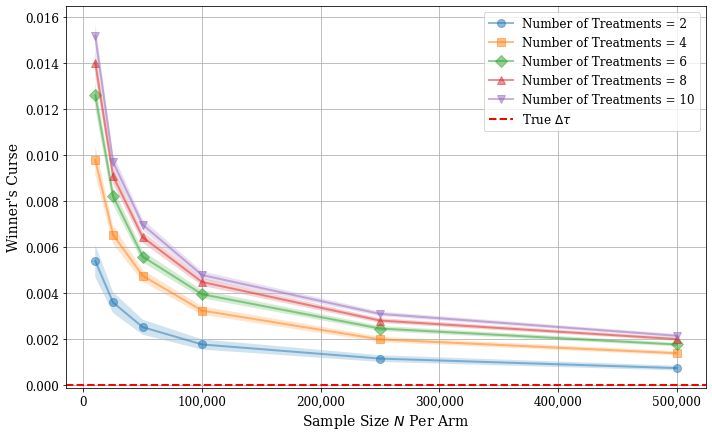

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

markers_list = ['o', 's', 'D', '^', 'v', 'x']

# plot the winner's curse as a function of the sample size for each number of treatments
for idx, n_treatments in enumerate(n_treatments_list):
    bar_values = [result_dict['wc_avg'] for result_dict in cont_result_records if result_dict['n_treatments'] == n_treatments]
    bar_errors = [result_dict['wc_se'] for result_dict in cont_result_records if result_dict['n_treatments'] == n_treatments]

    ax.plot(
        sample_size_list, bar_values, label=f'Number of Treatments = {n_treatments}', 
        alpha=0.5, linewidth=2, 
        marker=markers_list[idx], markersize=8
    )
    ax.fill_between(
        sample_size_list, 
        np.array(bar_values) - 1.96 * np.array(bar_errors), 
        np.array(bar_values) + 1.96 * np.array(bar_errors), 
        alpha=0.2
    )

ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label=r'True $\Delta\tau$')

ax.set_xlabel(r'Sample Size $N$ Per Arm', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse', fontsize=axis_label_size)
x_ticks = [0, 100000, 200000, 300000, 400000, 500000]
ax.set_xticks(
    x_ticks, labels=[f'{x:,}' for x in x_ticks],
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.savefig('figures/rct_n_treatments_sample_size.png')
plt.show()